# News Source Pipeline
**Input files needed in working directory:**
- `media_sources_internship.csv`
- `sources_categorized_with_breakdown.csv`

**Output files produced:**
- `respondent_subcategory_counts.csv`
- `respondent_subcategory_binary.csv`
- `name_mapping.xlsx`

## Imports

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

## Load data

In [2]:
raw = pd.read_csv('media_sources_internship.csv')
# load the file with categories assigned to each source by the LLM
cat_df = pd.read_csv('sources_categorized_with_breakdown.csv')
cat_df.columns = ['Source', 'Category']

# check number of respondents
raw['PROLIFIC_PID'].nunique()

928

In [3]:
# check number of sources and categories in the lookup file
cat_df['Category'].value_counts()

Category
Non-News Related               612
Local News                     330
News Creator                   315
Radio and Podcasts             205
Print & Digital News Outlet    120
National News Channel           44
News + Entertainment            31
Journalists & Hosts             23
Name: count, dtype: int64

## Define outlet columns and outlet groups

In [4]:
# social media columns
SM_COLS = ['Facebook', 'Instagram', 'TikTok', 'Twitter/X', 'YouTube']
# mainstream media columns
MM_COLS = ['TV news programs', 'online news sites', 'podcasts', 'printed newspapers', 'the radio']
# all outlet columns together
OUTLETS = SM_COLS + MM_COLS

# map each survey column to an outlet group
OUTLET_GROUP = {
    'TV news programs': 'TV/Radio',
    'the radio': 'TV/Radio',
    'printed newspapers': 'Print/Online',
    'online news sites': 'Print/Online',
    'YouTube': 'YouTube',
    'Facebook': 'Social Media',
    'Instagram': 'Social Media',
    'TikTok': 'Social Media',
    'Twitter/X': 'Social Media',
    'podcasts': 'Podcast',
}

## Step 1: Split each survey cell into individual source names

Each cell can contain multiple sources separated by commas, semicolons, slashes, newlines or colons.
We split on all of these.
Some source names contain the word 'and' so we only split on 'and' if it appears between two full source names.
A list of protected names prevents compound names like 'Breaking Points with Krystal and Saagar' from being broken apart.

In [5]:
# source names that must not be split even though they contain 'and'
PROTECTED = {
    'aba and preach',
    'faith and freedom coalition',
    'guns and butter',
    'law and crime',
    'crime and justice',
    'meet the press',
    'msnbc',
    'breaking points with krystal and saagar',
}

def split_sources(text):
    # split on common separators first
    segs = re.split(r'[;,\n:/]|\.\.\.+', text)
    result = []
    for seg in segs:
        # keep protected names intact
        if seg.strip().lower() in PROTECTED:
            result.append(seg)
            continue
        # split on 'and' without the 30-character restriction
        parts = re.split(r'\s+and\s+', seg, flags=re.IGNORECASE)
        for part in parts:
            result.append(part)
    # remove empty strings and strip whitespace
    return [s.strip() for s in result if s.strip()]

In [6]:
# go through every respondent and every outlet column
# create one row per source candidate
rows = []
for _, row in raw.iterrows():
    pid = row['PROLIFIC_PID'] # respondent id
    for outlet in OUTLETS:
        val = row.get(outlet)
        if pd.isna(val) or str(val).strip() == '':
            continue # skip empty cells
        for piece in split_sources(str(val)):
            rows.append({
                'prolific_id': pid,
                'outlet': outlet,
                'raw_text': piece,
                'col_type': 'SM' if outlet in SM_COLS else 'MM',
            })

exploded = pd.DataFrame(rows)
# check how many rows we have after splitting
len(exploded)

6373

## Step 2: Clean each candidate string

Lowercase everything, remove urls and domain endings, remove special characters, strip whitespace.

In [7]:
def clean(s):
    s = s.lower() # lowercase
    s = re.sub(r'https?://|www\.|//', '', s) # remove url prefixes
    s = re.sub(r'\.co\.uk|\.com|\.org|\.net|\.co|\.uk|\.gov|\.edu', '', s) # remove domain endings
    s = s.replace('_', ' ') # underscores to spaces
    s = re.sub(r"[@\"()\[\]]", '', s) # remove special characters
    s = s.encode('ascii', 'ignore').decode('ascii') # remove non-ascii
    return s.strip(' /.') # strip leading and trailing noise

exploded['cleaned'] = exploded['raw_text'].apply(clean) # apply cleaning to every row
exploded = exploded[exploded['cleaned'].str.len() > 0].copy() # drop empty strings after cleaning
# check how many rows remain
len(exploded)

6372

In [8]:
# check how many unique strings we have
exploded['cleaned'].nunique()

2527

## Step 3: Frequency table

Count how many times each cleaned string appears across all respondents and all outlets.
Strings that appear more than 3 times are treated as known sources and used in the next step.

In [9]:
freq = exploded['cleaned'].value_counts().reset_index()
freq.columns = ['source', 'count']
# cumulative percentage so we can see how much of all mentions the top sources cover
freq['cum_pct'] = (freq['count'].cumsum() / freq['count'].sum() * 100).round(1)
# keep only sources with more than 3 mentions
top3 = freq[freq['count'] > 3]
# how many unique frequent sources we have
len(top3)

161

In [10]:
# what percentage of all mentions these frequent sources cover
top3['count'].sum() / freq['count'].sum() * 100

np.float64(56.873822975517896)

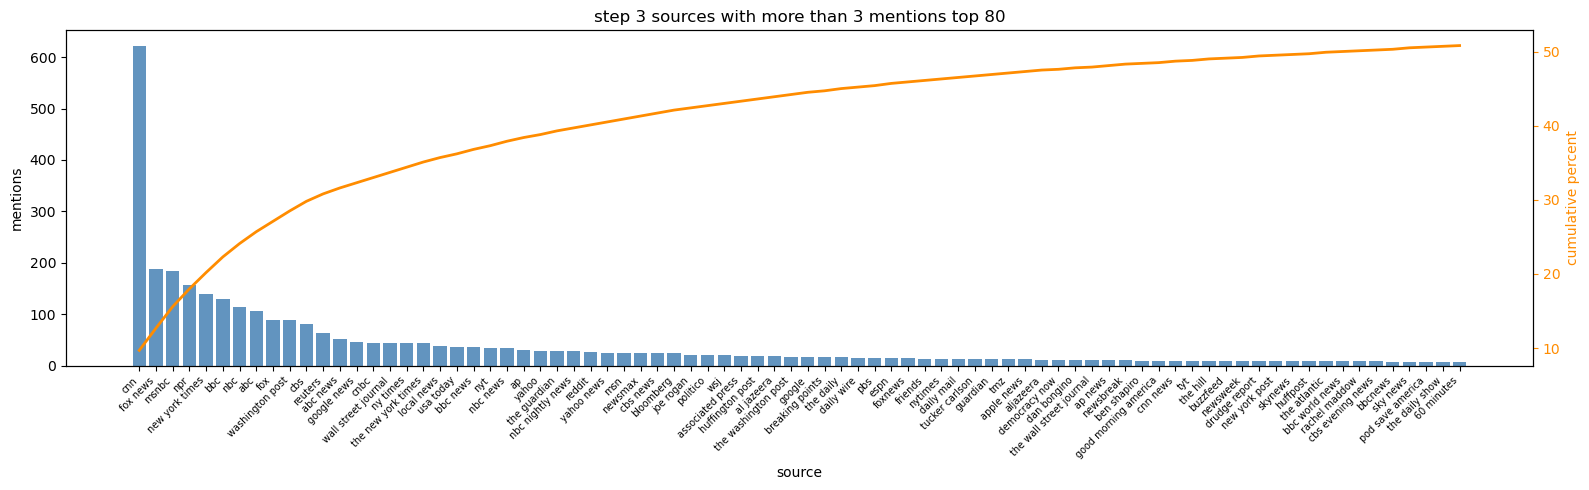

In [11]:
# bar chart of the most frequently mentioned sources after step 3
# each bar is one source, height is number of mentions
# the orange line shows the cumulative percentage of all mentions
fig, ax = plt.subplots(figsize=(16, 5))
ax2 = ax.twinx()
tp = top3.head(80) # show top 80
ax.bar(range(len(tp)), tp['count'], color='steelblue', alpha=0.85)
ax2.plot(range(len(tp)), tp['cum_pct'].values, color='darkorange', lw=2)
ax.set_xticks(range(len(tp)))
ax.set_xticklabels(tp['source'], rotation=45, ha='right', fontsize=7)
ax.set_xlabel('source')
ax.set_ylabel('mentions')
ax2.set_ylabel('cumulative percent', color='darkorange')
ax2.tick_params(axis='y', colors='darkorange')
ax.set_title('step 3 sources with more than 3 mentions top 80')
plt.tight_layout()
plt.savefig('fig1_step3_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Extract known source names from long strings

Some respondents wrote full sentences like 'I get my news from CNN and BBC'.
After splitting and cleaning this becomes 'i get my news from cnn' and 'bbc'.
The first part still contains a known source name.
We scan every cleaned string for any known frequent source name appearing as a whole word.
If we find one we replace the whole string with just the source name.
If we find more than one we create a separate row for each.
This step increases the number of rows which is expected and correct.

In [12]:
# sort candidates longest first so longer names match before shorter substrings
candidates = sorted(top3['source'].tolist(), key=len, reverse=True)

def extract_frequent(s, cands):
    # find all known source names that appear as whole words in this string
    found = [n for n in cands if re.search(r'\b' + re.escape(n) + r'\b', s)]
    if found:
        return found # return the found names
    return [s] # return the original string if nothing found

# apply extraction to every cleaned string
step4_lists = exploded['cleaned'].apply(lambda s: extract_frequent(s, candidates))
step4_series = step4_lists.explode().reset_index(drop=True)

# replicate the metadata rows to match the expanded series
meta = exploded.loc[exploded.index.repeat(step4_lists.apply(len))].reset_index(drop=True).copy()
meta = meta[['prolific_id', 'outlet', 'cleaned', 'col_type']].copy()
meta['source_step4'] = step4_series.values

In [13]:
# how many rows after extraction (should be more than before due to sentence splitting)
len(meta)

7451

In [14]:
# how many rows were added by extraction
len(meta) - len(exploded)

1079

In [15]:
# preview the table
meta

,prolific_id,outlet,cleaned,col_type,source_step4
0,5beddd59e4dbf300011c1d50,Facebook,music,SM,music
1,5beddd59e4dbf300011c1d50,Facebook,film news from bands,SM,film news from bands
2,5beddd59e4dbf300011c1d50,Facebook,movie,SM,movie
3,5beddd59e4dbf300011c1d50,Facebook,show pages that i follow like the black keys,SM,show pages that i follow like the black keys
4,5beddd59e4dbf300011c1d50,Facebook,meshuggah,SM,meshuggah
...,...,...,...,...,...
7446,658a8d7d92db39c7d5c8d69b,online news sites,washington post,MM,washington post
7447,658a8d7d92db39c7d5c8d69b,online news sites,ncb news,MM,ncb news
7448,658a8d7d92db39c7d5c8d69b,online news sites,google news,MM,google news
7449,658a8d7d92db39c7d5c8d69b,online news sites,google news,MM,google


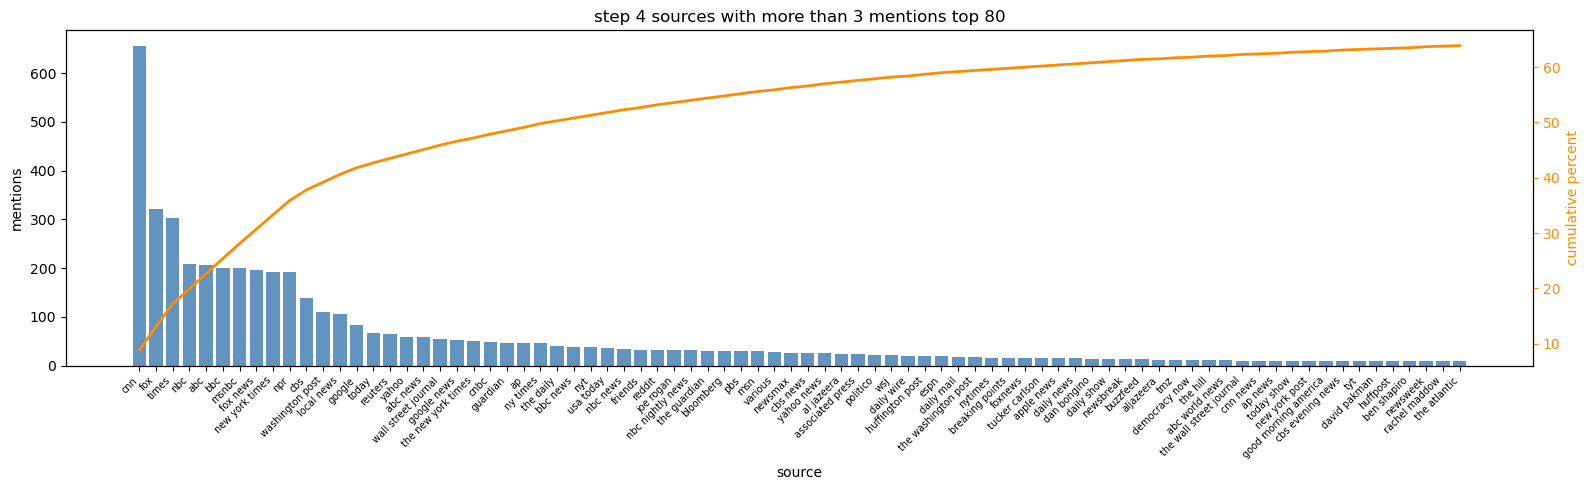

In [16]:
# bar chart of most frequent sources after step 4
freq4 = meta['source_step4'].value_counts().reset_index()
freq4.columns = ['source', 'count']
freq4['cum_pct'] = (freq4['count'].cumsum() / freq4['count'].sum() * 100).round(1)
tp4 = freq4[freq4['count'] > 3].head(80)

fig, ax = plt.subplots(figsize=(16, 5))
ax2 = ax.twinx()
ax.bar(range(len(tp4)), tp4['count'], color='steelblue', alpha=0.85) # same blue as step 3
ax2.plot(range(len(tp4)), tp4['cum_pct'].values, color='darkorange', lw=2)
ax.set_xticks(range(len(tp4)))
ax.set_xticklabels(tp4['source'], rotation=45, ha='right', fontsize=7)
ax.set_xlabel('source')
ax.set_ylabel('mentions')
ax2.set_ylabel('cumulative percent', color='darkorange')
ax2.tick_params(axis='y', colors='darkorange')
ax.set_title('step 4 sources with more than 3 mentions top 80')
plt.tight_layout()
plt.savefig('fig2_step4_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: Standardise source names

The same source appears under many different spellings in the raw data.
For example 'fox', 'foxnews', 'fox_news' all refer to Fox News.
We apply a lookup table that maps every known spelling variant to one standard name.
Strings that are too generic or meaningless (like 'news' or 'various') are marked as noise and removed.
This step reduces the number of rows because noise is removed.

In [17]:
# exact strings that are too generic to be a source name
NOISE_EXACT = {
    'n/a', 'na', 'n', 'a', 'no', 'none', 'nothing', 'not sure', 'various', 'many', 'other',
    'others', 'posts', 'ads', 'them', 'users', 'content', 'creators', 'trending',
    'explore page', 'news feed', 'for you page', 'my feed', 'impact',
    'no specific sources', 'no specific accounts', 'not specific',
    'nothing specific', 'nothing specific at all', 'source names unknown',
    'independent journalists', 'random people', 'forum links', 'advertisements',
    'just following links from elsewhere', 'only what shows up in my feed',
    'i just read my feed', 'random people who appear on my for you page',
    'rap', 'democrats', 'newstoday', 'america news',
    'times', 'news', 'post', 'daily', 'report', 'review', 'online',
    'media', 'channel', 'network', 'radio', 'tv', 'web',
}

# patterns that indicate a string is not a source name
NOISE_PAT = [
    r'^\d+$',
    r'^[a-z]$',
    r'\bjust\s+follow',
    r'\bonly\s+what\s+shows',
    r'\brandom\s+people\b',
    r'\bfor\s+you\s+page\b',
    r'\bmy\s+feed\b',
    r'\bnews\s+feed\b',
    r'\bno\s+specific\b',
    r'\bnothing\s+specific\b',
    r'\bsource\s+names\s+unknown\b',
]

# strip platform name prefix from things like 'youtube: penguinz0'
PLATFORM_PFX = r'^(?:youtube|tiktok|instagram|ig|facebook|fb|twitter|x|reddit|snapchat)\s*[-:./]\s*'

In [18]:
# lookup table mapping every known spelling variant to a standard name
# left side is a regex pattern matching all known variants of a source
# right side is the standard name we want to use
ALIAS_MAP = [
    (r'\bthe\s+new\s+york\s+times?\b', 'New York Times'),
    (r'\bnew\s+york\s+times?\b', 'New York Times'),
    (r'\bnytimes?\b', 'New York Times'),
    (r'\bny\s+times?\b', 'New York Times'),
    (r'\bnyt\b', 'New York Times'),
    (r'\bnew\s*york\s*tomes?\b', 'New York Times'),
    (r'\bnewyorktimes?\b', 'New York Times'),
    (r'\bcnn\s*news?\b', 'CNN'),
    (r'\bcnn\b', 'CNN'),
    (r'\bcnnbbc\b', 'CNN'),
    (r'\bcnncnn\b', 'CNN'),
    (r'\bfox\s+news\b', 'Fox News'),
    (r'\bfoxnews\b', 'Fox News'),
    (r'\blivenow\s+from\s+fox\b', 'Fox News'),
    (r'\bfox\b(?!\s*\d)', 'Fox News'),
    (r'\bbbcnews\b', 'BBC News'),
    (r'\bbbc\s+world\s+news\b', 'BBC News'),
    (r'\bbbc\s+world\b', 'BBC News'),
    (r'\bbbc(?:\s+news)?\b', 'BBC News'),
    (r'\bbcc\b', 'BBC News'),
    (r'\bthe\s+washington\s+post\b', 'Washington Post'),
    (r'\bwashington\s+post\b', 'Washington Post'),
    (r'\bwapo\b', 'Washington Post'),
    (r'\bwashpost\b', 'Washington Post'),
    (r'\bwashingtonpost\b', 'Washington Post'),
    (r'\btwp\b', 'Washington Post'),
    (r'\bwashinton\s+post\b', 'Washington Post'),
    (r'\bwash\s+post\b', 'Washington Post'),
    (r'\bwapost\b', 'Washington Post'),
    (r'\bmsnbc\b', 'MSNBC'),
    (r'\bnsnbc\b', 'MSNBC'),
    (r'\bmsmbc\b', 'MSNBC'),
    (r'\bnbc\s+nightly\s+news\b', 'NBC News'),
    (r'\bnbc\s+washington\b', 'NBC News'),
    (r'\bnbc(?:\s+news)?\b', 'NBC News'),
    (r'\bnbcnews\b', 'NBC News'),
    (r'\bnbc4\b', 'NBC News'),
    (r'\bnbc\s*4\b', 'NBC News'),
    (r'\bncb\s+news\b', 'NBC News'),
    (r'\bnightly\s+news\b', 'NBC News'),
    (r'\babc\s+world\s+news\b', 'ABC News'),
    (r'\bgood\s+morning\s+america\b', 'ABC News'),
    (r'\babc\s*\d+\s*(?:news)?\b', 'ABC News'),
    (r'\babc(?:\s+news)?\b', 'ABC News'),
    (r'\babcnews\b', 'ABC News'),
    (r'\bworld\s+news\s+tonight\b', 'ABC News'),
    (r'\bcbs\s+evening\s+news\b', 'CBS News'),
    (r'\b60\s+minutes\b', 'CBS News'),
    (r'\bcbs(?:\s+news)?\b', 'CBS News'),
    (r'\bcbsnews\b', 'CBS News'),
    (r'\bcbsboston\b', 'CBS News'),
    (r'\bface\s+the\s+nation\b', 'CBS News'),
    (r'\bnpr\b', 'NPR'),
    (r'\bnational\s+public\s+radio\b', 'NPR'),
    (r'\bnpr\s+news\b', 'NPR'),
    (r'\bup\s+first\b', 'NPR'),
    (r'\bmorning\s+edition\b', 'NPR'),
    (r'\ball\s+things\s+considered\b', 'NPR'),
    (r'\bfresh\s+air\b', 'NPR'),
    (r'\bpbs(?:\s+news(?:hour)?)?\b', 'PBS NewsHour'),
    (r'\bassociated\s+press\b', 'Associated Press'),
    (r'\bapnews\b', 'Associated Press'),
    (r'\bap\s+news\b', 'Associated Press'),
    (r'\bap\b', 'Associated Press'),
    (r'\bassosciated\s+press\b', 'Associated Press'),
    (r'\breuters\b', 'Reuters'),
    (r'\brueters\b', 'Reuters'),
    (r'\bthe\s+wall\s+street\s+journal\b', 'Wall Street Journal'),
    (r'\bwall\s+street\s+journal\b', 'Wall Street Journal'),
    (r'\bwallstreet\s+journal\b', 'Wall Street Journal'),
    (r'\bwsj\b', 'Wall Street Journal'),
    (r'\bwallstreetjournal\b', 'Wall Street Journal'),
    (r'\bwallstreetjurnal\b', 'Wall Street Journal'),
    (r'\bwall\s+st\s+journal\b', 'Wall Street Journal'),
    (r'\bal\s+jazeera\b', 'Al Jazeera'),
    (r'\baljazeera\b', 'Al Jazeera'),
    (r'\bal-jazeera\b', 'Al Jazeera'),
    (r'\baj\s+plus\b', 'Al Jazeera'),
    (r'\baj\s+english\b', 'Al Jazeera'),
    (r'\bajenglish\b', 'Al Jazeera'),
    (r'\baljazeeraenglish\b', 'Al Jazeera'),
    (r'\baljasera\b', 'Al Jazeera'),
    (r'\baljazzira\b', 'Al Jazeera'),
    (r'\bajazeera\b', 'Al Jazeera'),
    (r'\byahoo(?:\s+news)?\b', 'Yahoo News'),
    (r'\bgoogle(?:\s+news)?\b', 'Google News'),
    (r'\bapple\s+news\b', 'Apple News'),
    (r'\bmsn\b', 'MSN News'),
    (r'\bflipboard\b', 'Flipboard'),
    (r'\bground\s+news\b', 'Ground News'),
    (r'\bnews\s*break\b', 'NewsBreak'),
    (r'\b1440\b', '1440 Daily Digest'),
    (r'\bsmart\s*news\b', 'SmartNews'),
    (r'\bhaystack\b', 'Haystack News'),
    (r'\bhaystack\s+news\s+streaming\b', 'Haystack News'),
    (r'\bbing\b(?!\s+news)', 'Bing News'),
    (r'\bbing\s+news\s+app\b', 'Bing News'),
    (r'\bnews\s+aggregate\b', 'News Aggregator'),
    (r'\bnews\s+aggregator\b', 'News Aggregator'),
    (r'\bgoogles?\s+homepage\b', 'Google News'),
    (r'\bgoogles?\s+recommendations?\b', 'Google News'),
    (r'\bjust\s+googles?\s+recommendations?\b', 'Google News'),
    (r'\bi\s+get\s+a\s+lot\s+of\s+my\s+news\b', 'Google News'),
    (r'\bi\s+just\s+click\s+links\b', 'News Aggregator'),
    (r'\bwhatever\s+my\s+news\s+aggregator\b', 'News Aggregator'),
    (r'\bfacebook\b', 'Facebook'),
    (r'\bfb\b', 'Facebook'),
    (r'\binstagram\b', 'Instagram'),
    (r'\big\b(?!n)', 'Instagram'),
    (r'\btiktok\b', 'TikTok'),
    (r'\btwitter\b', 'Twitter/X'),
    (r'\bx\.com\b', 'Twitter/X'),
    (r'\byoutube\s+shorts\b', 'YouTube'),
    (r'\byoutube\b', 'YouTube'),
    (r'\byt\b', 'YouTube'),
    (r'\breddit\b', 'Reddit'),
    (r'\bsnapchat\b', 'Snapchat'),
    (r'\bdiscord\b', 'Discord'),
    (r'\bpinterest\b', 'Pinterest'),
    (r'\blinkedin\b', 'LinkedIn'),
    (r'\bthreads\b', 'Threads'),
    (r'\bbluesky\b', 'Bluesky'),
    (r'\bmastodon\b', 'Mastodon'),
    (r'\btwitch\b', 'Twitch'),
    (r'\bspotify\b', 'Spotify'),
    (r'\bsubstack\b', 'Substack'),
    (r'\bpatreon\b', 'Substack'),
    (r'\busa\s+today\b', 'USA Today'),
    (r'\busatoday\b', 'USA Today'),
    (r'\bla\s+times\b', 'Los Angeles Times'),
    (r'\blos\s+angeles\s+times\b', 'Los Angeles Times'),
    (r'\blatimes\b', 'Los Angeles Times'),
    (r'\bboston\s+globe\b', 'Boston Globe'),
    (r'\bnewsweek\b', 'Newsweek'),
    (r'\bpolitico\b', 'Politico'),
    (r'\bbloomberg\b', 'Bloomberg'),
    (r'\bbloonberg\b', 'Bloomberg'),
    (r'\bbloomburge\b', 'Bloomberg'),
    (r'\bbloombergbusiness\b', 'Bloomberg'),
    (r'\bcnbc\b', 'CNBC'),
    (r'\bforbes\b', 'Forbes'),
    (r'\bthe\s+economist\b', 'The Economist'),
    (r'\beconomist\b', 'The Economist'),
    (r'\bfinancial\s+times\b', 'Financial Times'),
    (r'\bvox\b', 'Vox'),
    (r'\bthe\s+atlantic\b', 'The Atlantic'),
    (r'\batlantic\b', 'The Atlantic'),
    (r'\bnew\s+yorker\b', 'The New Yorker'),
    (r'\bnew\s+york\s+mag\b', 'New York Magazine'),
    (r'\bnew\s+york\s+magazine\b', 'New York Magazine'),
    (r'\bthe\s+guardian\b', 'The Guardian'),
    (r'\bguardian\b', 'The Guardian'),
    (r'\btheguardian\b', 'The Guardian'),
    (r'\baxios\b', 'Axios'),
    (r'\bthe\s+hill\b', 'The Hill'),
    (r'\bhuffpost\b', 'HuffPost'),
    (r'\bhuffington\s+post\b', 'HuffPost'),
    (r'\bhuff\s+post\b', 'HuffPost'),
    (r'\bhuffnews\b', 'HuffPost'),
    (r'\bhiffpost\b', 'HuffPost'),
    (r'\bhiff\s+post\b', 'HuffPost'),
    (r'\bhuffingto\.?\s*post\b', 'HuffPost'),
    (r'\bhuffpo\b', 'HuffPost'),
    (r'\bbuzzfeed\b', 'BuzzFeed'),
    (r'\bespn\b', 'ESPN'),
    (r'\bbreitbart\b', 'Breitbart'),
    (r'\bbrietbart\b', 'Breitbart'),
    (r'\bbreibart\b', 'Breitbart'),
    (r'\bthe\s+daily\s+wire\b', 'Daily Wire'),
    (r'\bdaily\s+wire\b', 'Daily Wire'),
    (r'\bthe\s+blaze\b', 'The Blaze'),
    (r'\bdaily\s+mail\b', 'Daily Mail'),
    (r'\bdailymail\b', 'Daily Mail'),
    (r'\bnypost\b', 'New York Post'),
    (r'\bnew\s+york\s+post\b', 'New York Post'),
    (r'\bny\s+post\b', 'New York Post'),
    (r'\bnewsmax\b', 'Newsmax'),
    (r'\bnewsnation\b', 'NewsNation'),
    (r'\bnews\s*nation\b', 'NewsNation'),
    (r'\bdw\b', 'DW (Deutsche Welle)'),
    (r'\bdeutsche\s+welle\b', 'DW (Deutsche Welle)'),
    (r'\bpropublica\b', 'ProPublica'),
    (r'\bpro\s+publica\b', 'ProPublica'),
    (r'\btmz\b', 'TMZ'),
    (r'\bslate\b', 'Slate'),
    (r'\bvice\b', 'Vice'),
    (r'\bsalon\b', 'Salon'),
    (r'\bzerohedge\b', 'ZeroHedge'),
    (r'\bzero\s+hedge\b', 'ZeroHedge'),
    (r'\bmarketwatch\b', 'MarketWatch'),
    (r'\bmarket\s+watch\b', 'MarketWatch'),
    (r'\btelemundo\b', 'Telemundo'),
    (r'\bunivision\b', 'Univision'),
    (r'\bcbc\b', 'CBC'),
    (r'\bc-?span\b', 'C-SPAN'),
    (r'\bdrudge\s*report\b', 'Drudge Report'),
    (r'\bdrudge\b(?!\s*report)', 'Drudge Report'),
    (r'\bpolitifact\b', 'PolitiFact'),
    (r'\bsnopes\b', 'Snopes'),
    (r'\bbarstool(?:\s+sports)?\b', 'Barstool Sports'),
    (r'\bthe\s+shade\s+room\b', 'The Shade Room'),
    (r'\bshade\s+room\b', 'The Shade Room'),
    (r'\bthe\s+shaderoom\b', 'The Shade Room'),
    (r'\binside\s+edition\b', 'Inside Edition'),
    (r'\bmeidas\s*touch\b', 'MeidasTouch'),
    (r'\bmeidas\b(?!\s*touch)', 'MeidasTouch'),
    (r'\bmedias?\s*touch\b', 'MeidasTouch'),
    (r'\bmediastouch\b', 'MeidasTouch'),
    (r'\bmidas\s+touch\s+network\b', 'MeidasTouch'),
    (r'\boccupy\s+democrats\b', 'Occupy Democrats'),
    (r'\bthe\s+athletic\b', 'The Athletic'),
    (r'\bathletic\b', 'The Athletic'),
    (r'\bthe\s+intercept\b', 'The Intercept'),
    (r'\bintercept\b', 'The Intercept'),
    (r'\bjacobins?\b', 'Jacobin'),
    (r'\bjacobian\b', 'Jacobin'),
    (r'\bthe\s+bulwark\b', 'The Bulwark'),
    (r'\bbulwark\b', 'The Bulwark'),
    (r'\bbusiness\s+insider\b', 'Business Insider'),
    (r'\binsider\b(?!\s+edition)', 'Business Insider'),
    (r'\bjerusalem\s+post\b', 'Jerusalem Post'),
    (r'\btimes\s+of\s+israel\b', 'Times Of Israel'),
    (r'\bchicago\s+tribune\b', 'Chicago Tribune'),
    (r'\bdetroit\s+free\s+press\b', 'Detroit Free Press'),
    (r'\bstar\s+tribune\b', 'Star Tribune'),
    (r'\bstart\s+tribune\b', 'Star Tribune'),
    (r'\bstar\s+tribnue\b', 'Star Tribune'),
    (r'\btampa\s+bay\s+times\b', 'Tampa Bay Times'),
    (r'\btampabaytimes\b', 'Tampa Bay Times'),
    (r'\btexas\s+tribune\b', 'Texas Tribune'),
    (r'\bepoch\s+times\b', 'Epoch Times'),
    (r'\bnational\s+review\b', 'National Review'),
    (r'\bthe\s+telegraph\b', 'The Telegraph'),
    (r'\btelegraph\b', 'The Telegraph'),
    (r'\btelegraph\s+harold\b', 'The Telegraph'),
    (r'\bwashington\s+examiner\b', 'Washington Examiner'),
    (r'\bthe\s+independent\b', 'The Independent'),
    (r'\bgateway\s+pundit\b', 'Gateway Pundit'),
    (r'\bthegatewaypundit\b', 'Gateway Pundit'),
    (r'\boann?\b', 'OAN'),
    (r'\breal\s+americas?\s+voice\b', "Real America's Voice"),
    (r'\bblazetv\b', 'BlazeTV'),
    (r'\bblaze\s+tv\b', 'BlazeTV'),
    (r'\bspectrum\s+news\b', 'Spectrum News'),
    (r'\bdaily\s+beast\b', 'Daily Beast'),
    (r'\bpink\s+news\b', 'PinkNews'),
    (r'\bmiddle\s+east\s+eye\b', 'Middle East Eye'),
    (r'\bmiddle\s+eastern\s+eye\b', 'Middle East Eye'),
    (r'\bvoa\b', 'Voice of America'),
    (r'\bvoice\s+of\s+america\b', 'Voice of America'),
    (r'\bwion\b', 'WION'),
    (r'\bi24\s*news\b', 'i24News'),
    (r'\bglobal\s+news\b', 'Global News'),
    (r'\bdisclose\.?tv\b', 'Disclose.tv'),
    (r'\bny\s+daily\s+news\b', 'NY Daily News'),
    (r'\bnydailynews\b', 'NY Daily News'),
    (r'\bus\s+news\b', 'US News'),
    (r'\busnews\b', 'US News'),
    (r'\bupi\b', 'UPI'),
    (r'\bunited\s+press\s+international\b', 'UPI'),
    (r'\bvariety\b', 'Variety'),
    (r'\bmasslive\b', 'MassLive'),
    (r'\bpennlive\b', 'PennLive'),
    (r'\bpenn\s*live\b', 'PennLive'),
    (r'\bsacramento\s+bee\b', 'Sacramento Bee'),
    (r'\bsacbee\b', 'Sacramento Bee'),
    (r'\bthe\s+sacramento\s+bee\b', 'Sacramento Bee'),
    (r'\bindianapolis\s+star\b', 'Indianapolis Star'),
    (r'\bindy\s+star\b', 'Indianapolis Star'),
    (r'\bsan\s+francisco\s+chronicle\b', 'San Francisco Chronicle'),
    (r'\bsan\s+diego\s+union\s*[-\u2013]?\s*tribune\b', 'San Diego Union-Tribune'),
    (r'\blas\s+vegas\s+review\s*[-\u2013]?\s*journal\b', 'Las Vegas Review-Journal'),
    (r'\blas\s+vegas\s+sun\b', 'Las Vegas Sun'),
    (r'\bomaha\s+world\s*[-\u2013]?\s*herald\b', 'Omaha World-Herald'),
    (r'\bbuffalo\s+news\b', 'Buffalo News'),
    (r'\bthe\s+buffalo\s+news\b', 'Buffalo News'),
    (r'\bcharlotte\s+observer\b', 'Charlotte Observer'),
    (r'\bthe\s+charlotte\s+observer\b', 'Charlotte Observer'),
    (r'\bprovidence\s+journal\b', 'Providence Journal'),
    (r'\bthe\s+providence\s+journal\b', 'Providence Journal'),
    (r'\barkansas\s+democrat\s*[-\u2013]?\s*gazette\b', 'Arkansas Democrat-Gazette'),
    (r'\bgreen\s+bay\s+press\s*[-\u2013]?\s*gazette\b', 'Green Bay Press-Gazette'),
    (r'\bgreenbrier\s+news\b', 'Greenbrier News'),
    (r'\bsarasota\s+herald\s*[-\u2013]?\s*tribune\b', 'Sarasota Herald-Tribune'),
    (r'\bmercury\s+news\b', 'Mercury News'),
    (r'\bmercury\s+news\s+san\s+jose\b', 'Mercury News'),
    (r'\bphiladelphia\s+inqui[re]+r?\b', 'Philadelphia Inquirer'),
    (r'\bphiladelphia\s+inquire\b', 'Philadelphia Inquirer'),
    (r'\batlanta\s+journal[\s\-]+constitution\b', 'Atlanta Journal-Constitution'),
    (r'\batlanta\s+journal\b', 'Atlanta Journal-Constitution'),
    (r'\bajc\b', 'Atlanta Journal-Constitution'),
    (r'\bthe\s+weather\s+channel\b', 'The Weather Channel'),
    (r'\bnewspaper\b', 'Print & Digital News Outlet'),
    (r'\bbn[o0]\s+news\b', 'BNO News'),
    (r'\bthe\s+beverly\s+hills\s+courier\b', 'Beverly Hills Courier'),
    (r'\bsirius\s*xm\b', 'SiriusXM'),
    (r'\bxm\s+radio\b', 'SiriusXM'),
    (r'\biheart\s*radio\b', 'iHeartRadio'),
    (r'\biheartradio\b', 'iHeartRadio'),
    (r'\biheart\b', 'iHeartRadio'),
    (r'\bthis\s+american\s+life\b', 'This American Life'),
    (r'\bpod\s+save\s+america\b', 'Pod Save America'),
    (r'\bpod\s+saves?\s+america\b', 'Pod Save America'),
    (r'\bbreaking\s+points\b', 'Breaking Points'),
    (r'\bdemocracy\s+now\b', 'Democracy Now'),
    (r'\bdem?ocracy\s*now!?\b', 'Democracy Now'),
    (r'\bthe\s+daily\b(?!\s+show|\s+wire)', 'The Daily'),
    (r'\bmorning\s+wire\b', 'Morning Wire'),
    (r'\bpbd\s+podcast\b', 'PBD Podcast'),
    (r'\bknx\s+1070\b', 'KNX 1070'),
    (r'\bknx\s+news\s+los\s+angeles\b', 'KNX 1070'),
    (r'\bknx\s+1070\s+news\s+radio\b', 'KNX 1070'),
    (r'\bnews\s*&\s*talk\s+840\b', 'News & Talk 840'),
    (r'\bnews\s+&\s+talk\s+840\s+am\b', 'News & Talk 840'),
    (r'\bwtmj\s*radio\b', 'WTMJ Radio'),
    (r'\bthe\s+daily\s+show\b', 'The Daily Show'),
    (r'\bdaily\s+show\b', 'The Daily Show'),
    (r'\bthe\s+view\b', 'The View'),
    (r'\blast\s+week\s+tonight\b', 'Last Week Tonight'),
    (r'\blastweektonight\b', 'Last Week Tonight'),
    (r'\bthis\s+week\s+tonight\b', 'Last Week Tonight'),
    (r'\bthe\s+young\s+turks\b', 'TYT'),
    (r'\byoung\s+turks\b', 'TYT'),
    (r'\btyt\b', 'TYT'),
    (r'\bmeet\s+the\s+press\b', 'Meet The Press'),
    (r'\bmorning\s+joe\b', 'Morning Joe'),
    (r'\btoday\s+show\b', 'Today Show'),
    (r'\btoday\b(?!\s+show)', 'Today Show'),
    (r'\bdateline\b', 'Dateline NBC'),
    (r'\bfrontline\b', 'Frontline'),
    (r'\bgutfeld\b', 'Gutfeld!'),
    (r'\bthe\s+five\b', 'The Five'),
    (r'\ball\s+in\s+with\s+chris\s+hayes\b', 'All In With Chris Hayes'),
    (r'\bjesse\s+watters\s+primetime\b', 'Jesse Watters Primetime'),
    (r'\bthe\s+ingraham\s+angle\b', 'The Ingraham Angle'),
    (r'\bthe\s+ringer\b', 'The Ringer'),
    (r'\bsean\s+hannity\b', 'Sean Hannity'),
    (r'\bhannity\b', 'Sean Hannity'),
    (r'\blaura\s+ingraham\b', 'Laura Ingraham'),
    (r'\bjesse\s+wat?ers?\b', 'Jesse Watters'),
    (r'\bjimmy\s+kimmel\b', 'Jimmy Kimmel'),
    (r'\bkimmel\b', 'Jimmy Kimmel'),
    (r'\brachel\s+maddow\b', 'Rachel Maddow'),
    (r'\banderson\s+cooper\b', 'Anderson Cooper'),
    (r'\blawrence\s+o.?donnell\b', "Lawrence O'Donnell"),
    (r'\blawrence\s+odonnell\b', "Lawrence O'Donnell"),
    (r'\bchris\s+hayes\b', 'Chris Hayes'),
    (r'\bari\s+melber\b', 'Ari Melber'),
    (r'\bstephen\s+colbert\b', 'Stephen Colbert'),
    (r'\bcolbert\b', 'Stephen Colbert'),
    (r'\bjoe\s+rogan\b', 'Joe Rogan'),
    (r'\bjoerogan\b', 'Joe Rogan'),
    (r'\brogan\b(?!\s+experience)', 'Joe Rogan'),
    (r'\btucker\s+carlson\b', 'Tucker Carlson'),
    (r'\btucker\b(?!\s+carlson)', 'Tucker Carlson'),
    (r'\bben\s+shapiro\b', 'Ben Shapiro'),
    (r'\bmegyn?\s+kell?e?y?\b', 'Megyn Kelly'),
    (r'\bmegan\s+kell?e?y?\b', 'Megyn Kelly'),
    (r'\bmegan\s+kelley\s+podcast\b', 'Megyn Kelly'),
    (r'\bhasanabi\b', 'Hasanabi'),
    (r'\bhasan\s+piker\b', 'Hasanabi'),
    (r'\bpenguinz0\b', 'Penguinz0'),
    (r'\btim\s+pool\b', 'Tim Pool'),
    (r'\btimcast\b', 'Tim Pool'),
    (r'\btimcastirl\b', 'Tim Pool'),
    (r'\bmatt\s+walsh\b', 'Matt Walsh'),
    (r'\bmatt\s+wallace\b', 'Matt Wallace'),
    (r'\bmatt\s+wallace\s+mattwallace888\b', 'Matt Wallace'),
    (r'\belon\s+musk\b', 'Elon Musk'),
    (r'\belonmusk\b', 'Elon Musk'),
    (r'\bjordan\s+peterson\b', 'Jordan Peterson'),
    (r'\bglenn?\s+greenwald\b', 'Glenn Greenwald'),
    (r'\bglen\s+greenwald\b', 'Glenn Greenwald'),
    (r'\bcharlie\s+kirk\b', 'Charlie Kirk'),
    (r'\bmark\s+levin\b', 'Mark Levin'),
    (r'\bglenn\s+beck\b', 'Glenn Beck'),
    (r'\brussell\s+brand\b', 'Russell Brand'),
    (r'\brusselbrand\b', 'Russell Brand'),
    (r'\bcandace\s+owens\b', 'Candace Owens'),
    (r'\bcandice\s+owens\b', 'Candace Owens'),
    (r'\bcandice\s+owens\s+podcast\b', 'Candace Owens'),
    (r'\bdan\s+bongino\b', 'Dan Bongino'),
    (r'\bbongino\b', 'Dan Bongino'),
    (r'\bdan\s+borgino\b', 'Dan Bongino'),
    (r'\bdavid\s+pakman\b', 'David Pakman'),
    (r'\bdpakman\b', 'David Pakman'),
    (r'\bphilip\s+de\s*franco\b', 'Philip DeFranco'),
    (r'\bphil\s+defranco\b', 'Philip DeFranco'),
    (r'\bphilip\s+defranco\b', 'Philip DeFranco'),
    (r'\bphilipp?\s*defranco\b', 'Philip DeFranco'),
    (r'\bphil\s+de\s*franco\b', 'Philip DeFranco'),
    (r'\bphilip\s+difranco\b', 'Philip DeFranco'),
    (r'\bphillip\s+defranco\b', 'Philip DeFranco'),
    (r'\bphillipdefranco\b', 'Philip DeFranco'),
    (r'\bpdefranco\b', 'Philip DeFranco'),
    (r'\bphilp\s+defranco\b', 'Philip DeFranco'),
    (r'\bbrian\s+tyler\s+cohen\b', 'Brian Tyler Cohen'),
    (r'\bbrian\s+tay(?:lor|ler)\s+cohen\b', 'Brian Tyler Cohen'),
    (r'\bjack\s+posobiec\b', 'Jack Posobiec'),
    (r'\bjack\s+posi?beic?\b', 'Jack Posobiec'),
    (r'\bmichael\s+knowles\b', 'Michael Knowles'),
    (r'\bjimmy\s+dore\b', 'Jimmy Dore'),
    (r'\bsam\s+seder\b', 'Sam Seder'),
    (r'\bdylan\s+page\b', 'Dylan Page'),
    (r'\bdylan\.page\b', 'Dylan Page'),
    (r'\bjonathan\s+turley\b', 'Jonathan Turley'),
    (r'\bgeorge\s+conway\b', 'George Conway'),
    (r'\bbeau\s+of\s+the\s+fifth\s+column\b', 'Beau of the Fifth Column'),
    (r'\bmajority\s+report\b', 'Majority Report'),
    (r'\bsecular\s+talk\b', 'Secular Talk'),
    (r'\bhumanist\s+report\b', 'Humanist Report'),
    (r'\bthe\s+rational\s+national\b', 'The Rational National'),
    (r'\brational\s+national\b', 'The Rational National'),
    (r'\bunder\s+the\s+desk\s+news\b', 'Under the Desk News'),
    (r'\bunderthedesknews\b', 'Under the Desk News'),
    (r'\bnews\s+under\s+the\s+desk\b', 'Under the Desk News'),
    (r'\bunder\s+the\s+news\s+desk\b', 'Under the Desk News'),
    (r'\bjohn\s+oliver\b', 'John Oliver'),
    (r'\bjon\s+stewart\b', 'Jon Stewart'),
    (r'\bjohn\s+stewart\b', 'Jon Stewart'),
    (r'\bseth\s+mey[oe]rs?\b', 'Seth Meyers'),
    (r'\bbill\s+maher\b', 'Bill Maher'),
    (r'\basmongold\b', 'Asmongold'),
    (r'\basmondgoldtv\b', 'Asmongold'),
    (r'\bmark\s+dice\b', 'Mark Dice'),
    (r'\bandy\s+ngo\b', 'Andy Ngo'),
    (r'\bwbal\b', 'WBAL'),
    (r'\bwbbm\b', 'WBBM'),
    (r'\bwfla\b', 'WFLA'),
    (r'\bwsvn\b', 'WSVN'),
    (r'\bwsbtv\b', 'WSB-TV'),
    (r'\bwplg\b', 'WPLG'),
    (r'\bkcci\b', 'KCCI'),
    (r'\bkake\b', 'KAKE'),
    (r'\bkfyr\b', 'KFYR'),
    (r'\bkcrg\b', 'KCRG'),
    (r'\bkfvs\b', 'KFVS'),
    (r'\bktla\b', 'KTLA'),
    (r'\bktla5\b', 'KTLA'),
    (r'\bktla5cw\b', 'KTLA'),
    (r'\bksl\b', 'KSL'),
    (r'\bkare\s*11\b', 'KARE 11'),
    (r'\bwkbn\b', 'WKBN'),
    (r'\bwcco\b', 'WCCO'),
    (r'\bwesh\b', 'WESH'),
    (r'\bkhou\b', 'KHOU'),
    (r'\bkhou11\b', 'KHOU'),
    (r'\bkou11\b', 'KHOU'),
    (r'\bkstp\b', 'KSTP'),
    (r'\bkxan\b', 'KXAN'),
    (r'\bkdka\b', 'KDKA'),
    (r'\bny1\b', 'NY1'),
    (r'\bwgn\b', 'WGN'),
    (r'\bwabc\b', 'WABC'),
    (r'\bwabc\s+770\b', 'WABC'),
    (r'\bwnbc\b', 'WNBC'),
    (r'\bwafb\b', 'WAFB'),
    (r'\bwafb\s+news\b', 'WAFB'),
    (r'\bwave\s*3\b', 'WAVE 3'),
    (r'\bwavy\s*10\b', 'WAVY-TV 10'),
    (r'\bwavy10\b', 'WAVY-TV 10'),
    (r'\bwavy\s+tv\s+10\b', 'WAVY-TV 10'),
    (r'\bwbay\b', 'WBAY'),
    (r'\bwben\b', 'WBEN'),
    (r'\bwbko\b', 'WBKO'),
    (r'\bwbkolocal\s+news\b', 'WBKO'),
    (r'\bwboc\b', 'WBOC'),
    (r'\bwboc\s+news\b', 'WBOC'),
    (r'\bwbrc\b', 'WBRC'),
    (r'\bwbrc\s+news\b', 'WBRC'),
    (r'\bwbrz\b', 'WBRZ'),
    (r'\bwbrz\s+news\b', 'WBRZ'),
    (r'\bwbur\b', 'WBUR'),
    (r'\bwdbo\b', 'WDBO'),
    (r'\bwdrb\b', 'WDRB'),
    (r'\bwevh\b', 'WEVH'),
    (r'\bwfmz\b', 'WFMZ'),
    (r'\bwfsb\b', 'WFSB'),
    (r'\bwgal\b', 'WGAL'),
    (r'\bwgal\s+news\b', 'WGAL'),
    (r'\bwgau\b', 'WGAU'),
    (r'\bwgau\s+1340\b', 'WGAU'),
    (r'\bwgrc\b', 'WGRC'),
    (r'\bwgrz\b', 'WGRZ'),
    (r'\bwgts\b', 'WGTS'),
    (r'\bwhec\b', 'WHEC'),
    (r'\bwhio\b', 'WHIO'),
    (r'\bwhnt\b', 'WHNT'),
    (r'\bwho\s*13\b', 'WHO-TV'),
    (r'\bwho13\s+local\b', 'WHO-TV'),
    (r'\bwicr\b', 'WICR'),
    (r'\bwicr\s+local\b', 'WICR'),
    (r'\bwis\b', 'WIS'),
    (r'\bwis\s+news\s+10\b', 'WIS'),
    (r'\bwitn\b', 'WITN'),
    (r'\bwitn\s+page\b', 'WITN'),
    (r'\bwjhl\b', 'WJHL'),
    (r'\bwjz\b', 'WJZ'),
    (r'\bwjbo\b', 'WJBO'),
    (r'\bwjbo\s+talk\s+radio\b', 'WJBO'),
    (r'\bwkrg\b', 'WKRG'),
    (r'\bwkyc\b', 'WKYC'),
    (r'\bwkyc\s+tv\s+cleveland\b', 'WKYC'),
    (r'\bwlbt\b', 'WLBT'),
    (r'\bwlky\b', 'WLKY'),
    (r'\bwlns\b', 'WLNS'),
    (r'\bwlns\s+6\s+news\b', 'WLNS'),
    (r'\bwlox\b', 'WLOX'),
    (r'\bwlox\s+local\b', 'WLOX'),
    (r'\bwltx\b', 'WLTX'),
    (r'\bwltx\s+at\s+7\b', 'WLTX'),
    (r'\bwmal\b', 'WMAL'),
    (r'\bwmal-fm\b', 'WMAL'),
    (r'\bwmar\b', 'WMAR'),
    (r'\bwnep\b', 'WNEP'),
    (r'\bwnep\s+local\b', 'WNEP'),
    (r'\bwnsc\b', 'WNSC'),
    (r'\bwnsc-tv\b', 'WNSC'),
    (r'\bwoai\b', 'WOAI'),
    (r'\bwogb\b', 'WOGB'),
    (r'\bwpro\b', 'WPRO'),
    (r'\bwrko\b', 'WRKO'),
    (r'\bwsfa\b', 'WSFA'),
    (r'\bwson\b', 'WSON'),
    (r'\bwtae\b', 'WTAE'),
    (r'\bwtaj\b', 'WTAJ'),
    (r'\bwtaj\s+replay\b', 'WTAJ'),
    (r'\bwthr\b', 'WTHR'),
    (r'\bwtnh\b', 'WTNH'),
    (r'\bwtol\b', 'WTOL'),
    (r'\bwtol11\b', 'WTOL'),
    (r'\bwvbo\b', 'WVBO'),
    (r'\bwvla\b', 'WVLA'),
    (r'\bwvla\s+news\b', 'WVLA'),
    (r'\bwvlt\b', 'WVLT'),
    (r'\bwwdc\b', 'WWDC'),
    (r'\bwwdc-fm\b', 'WWDC'),
    (r'\bwwj\b', 'WWJ'),
    (r'\bwwj\s+am\s+radio\b', 'WWJ'),
    (r'\bwwj\s+morning\s+news\b', 'WWJ'),
    (r'\bwymt\b', 'WYMT'),
    (r'\bkbtx\b', 'KBTX'),
    (r'\bkbtx\s+media\b', 'KBTX'),
    (r'\bkcal\b', 'KCAL'),
    (r'\bkcal\s+news\b', 'KCAL'),
    (r'\bkatc\b', 'KATC'),
    (r'\bkens\b', 'KENS'),
    (r'\bkgw\b', 'KGW'),
    (r'\bkiro\b', 'KIRO'),
    (r'\bkiro\s+tv\b', 'KIRO'),
    (r'\bking\s*tv\b', 'KING TV'),
    (r'\bkoco\b', 'KOCO'),
    (r'\bkotv\b', 'KOTV'),
    (r'\bkptvfox\b', 'KPTV'),
    (r'\bkrgv\b', 'KRGV'),
    (r'\bkrgv\s+channel\s+5\b', 'KRGV'),
    (r'\bksat\b', 'KSAT'),
    (r'\bksat\s+tv\b', 'KSAT'),
    (r'\bkstv\b', 'KSTV'),
    (r'\bkstv-fm\b', 'KSTV'),
    (r'\bkstx\b', 'KSTX'),
    (r'\bktck\b', 'KTCK'),
    (r'\bktck\s+the\s+ticket\b', 'KTCK'),
    (r'\bkten\b', 'KTEN'),
    (r'\bkten\s+news\b', 'KTEN'),
    (r'\bktnv\b', 'KTNV'),
    (r'\bktnv\s+las\s+vegas\b', 'KTNV'),
    (r'\bktvz\b', 'KTVZ'),
    (r'\bktvz\s+news\b', 'KTVZ'),
    (r'\bkwqc\b', 'KWQC'),
    (r'\bkwwl\b', 'KWWL'),
    (r'\bkduc\b', 'KDUC'),
    (r'\brtv6\b', 'RTV6'),
    (r'\bnecn\b', 'NECN'),
    (r'\bnecn\s+news\b', 'NECN'),
    (r'\bpix11\b', 'PIX11'),
    (r'\bpix11\s+news\b', 'PIX11'),
    (r'\bnews4jax\b', 'Action News Jax'),
    (r'\bwane\s*15\b', 'WANE 15'),
    (r'\bwane\s+15\s+news\b', 'WANE 15'),
    (r'\b13news\s*now\b', '13News Now'),
    (r'\b13newsnow\b', '13News Now'),
    (r'\bwxpn\b', 'WXPN'),
    (r'\bksen\b', 'KSEN'),
    (r'\bksen\s+local\b', 'KSEN'),
    (r'\bwtop\b', 'WTOP'),
    (r'\bwnyc\b', 'WNYC'),
    (r'\blocal\s+stations?\b', 'Local News'),
    (r'\blocal\s+new\s+stations?\b', 'Local News'),
    (r'\blocal\s+television\s+news\b', 'Local News'),
    (r'\blocal\s+station\s+\d+\b', 'Local News'),
    (r'\bmorning\s+shows\s+on\s+local\s+stations\b', 'Local News'),
    (r'\bany\s+of\s+the\s+network\s+news\b', 'Local News'),
    (r'\bevening\s+broadcast\s+news\b', 'Local News'),
    (r'\bnational\s+news\s+channels?\b', 'National TV News Channel'),
]

In [19]:
def unify(s):
    # strip platform prefix like 'youtube:' or 'tiktok -'
    s = re.sub(PLATFORM_PFX, '', s, flags=re.IGNORECASE).strip()
    s = re.sub(r'^[@#]', '', s) # remove leading at or hash
    s = re.sub(r'\s+', ' ', s).strip() # collapse multiple spaces
    if s in NOISE_EXACT:
        return 'NOISE' # discard generic strings
    for pat in NOISE_PAT:
        if re.search(pat, s):
            return 'NOISE' # discard noise patterns
    for pattern, standard_name in ALIAS_MAP:
        if re.search(pattern, s, re.IGNORECASE):
            return standard_name # return the standard name if pattern matches
    return s.title() # if no pattern matched title-case the string as is

meta['source_unified'] = meta['source_step4'].apply(unify) # apply to every row
before = len(meta)
meta_clean = meta[meta['source_unified'] != 'NOISE'].copy() # remove noise rows

In [20]:
# how many rows before noise removal
print(before)

7451


In [21]:
# how many noise rows removed
print(before - len(meta_clean))

458


In [22]:
# how many rows after noise removal
print(len(meta_clean))

6993


In [23]:
# how many unique standard names
meta_clean['source_unified'].nunique()

1698

## Export the name mapping to Excel

Two columns: what the respondent wrote (original string after step 4) and what standard name it was mapped to.
This lets you inspect and verify the standardisation.

In [24]:
wb = Workbook()
ws = wb.active
ws.title = 'name mapping'

thin = Side(style='thin', color='CCCCCC')
bdr = Border(left=thin, right=thin, top=thin, bottom=thin)
hdr_fill = PatternFill(fill_type='solid', fgColor='2E75B6')
alt_fill = PatternFill(fill_type='solid', fgColor='EBF3FB')
hdr_font = Font(name='Arial', bold=True, size=11, color='FFFFFF')
cell_font = Font(name='Arial', size=10)

# column headers
headers = ['original string', 'standard name']
widths = [55, 35]
for col, (h, w) in enumerate(zip(headers, widths), 1):
    c = ws.cell(row=1, column=col, value=h)
    c.font = hdr_font
    c.fill = hdr_fill
    c.border = bdr
    c.alignment = Alignment(horizontal='center', vertical='center')
    ws.column_dimensions[get_column_letter(col)].width = w
ws.row_dimensions[1].height = 28

# get all unique pairs of original string and standard name from the data
mapping_pairs = (
    meta_clean[['source_step4', 'source_unified']]
    .drop_duplicates()
    .sort_values('source_unified')
    .values.tolist()
)

for i, (orig, standard) in enumerate(mapping_pairs, start=2):
    fill = alt_fill if i % 2 == 0 else None # alternate row shading
    for col, val in enumerate([orig, standard], 1):
        c = ws.cell(row=i, column=col, value=val)
        c.font = cell_font
        c.border = bdr
        c.alignment = Alignment(horizontal='left', vertical='center')
        if fill:
            c.fill = fill

ws.freeze_panes = 'A2'
ws.auto_filter.ref = 'A1:B' + str(len(mapping_pairs) + 1)
wb.save('name_mapping.xlsx')
# how many unique mapping pairs saved
print(len(mapping_pairs))

2014


## Step 8: Join category from the categorization file

Each standard name is looked up in the file that contains the LLM-assigned categories.
Sources not found in that file are called uncategorized and dropped.

In [25]:
cat_lookup = dict(zip(cat_df['Source'], cat_df['Category'])) # build lookup dictionary
meta_clean = meta_clean.copy()
meta_clean['category'] = meta_clean['source_unified'].map(cat_lookup) # join category

total = len(meta_clean)
n_uncat = meta_clean['category'].isna().sum() # count uncategorized rows
pct_uncat = n_uncat / total * 100 # percentage uncategorized

In [26]:
# how many rows uncategorized
print(n_uncat)

108


In [27]:
# what percent of rows are uncategorized
print(round(pct_uncat, 1))

1.5


In [28]:
# which unique source names are uncategorized and how many mentions each
meta_clean[meta_clean['category'].isna()]['source_unified'].value_counts()

source_unified
Skynews                                                          8
Last Week Tonight                                                8
Dc News Now                                                      4
Marketplace                                                      2
Get Entertainment News From Figures That I Follow Like Arnold    1
                                                                ..
'Choeshow                                                        1
'Rap                                                             1
It'S Been A Minute                                               1
'Ajcnews                                                         1
I Don'T Follow Any Specific Accounts                             1
Name: count, Length: 90, dtype: int64

In [29]:
meta_clean = meta_clean[meta_clean['category'].notna()].copy() # drop uncategorized rows
# how many rows remain
len(meta_clean)

6885

## Step 9: Frequency chart after standardisation and categorization

Same chart as steps 3 and 4 but now showing standardised source names.
Blue bars show number of mentions, orange line shows cumulative percentage.

Most mentions are concentrated in a small number of well-known outlets like CNN and Fox News.
The long tail shows many sources mentioned only a few times.

In [30]:
freq6 = meta_clean['source_unified'].value_counts().reset_index()
freq6.columns = ['source', 'count']
freq6['cum_pct'] = (freq6['count'].cumsum() / freq6['count'].sum() * 100).round(1)
top6 = freq6[freq6['count'] > 3]

# how many unique sources remain
meta_clean['source_unified'].nunique()

1608

In [31]:
# top 20 sources by number of mentions
freq6.head(20)

,source,count,cum_pct
0,CNN,666,9.7
1,Fox News,532,17.4
2,New York Times,348,22.5
3,ABC News,305,26.9
4,NBC News,295,31.2
5,BBC News,263,35.0
6,NPR,215,38.1
7,MSNBC,202,41.0
8,CBS News,188,43.8
9,Washington Post,143,45.9


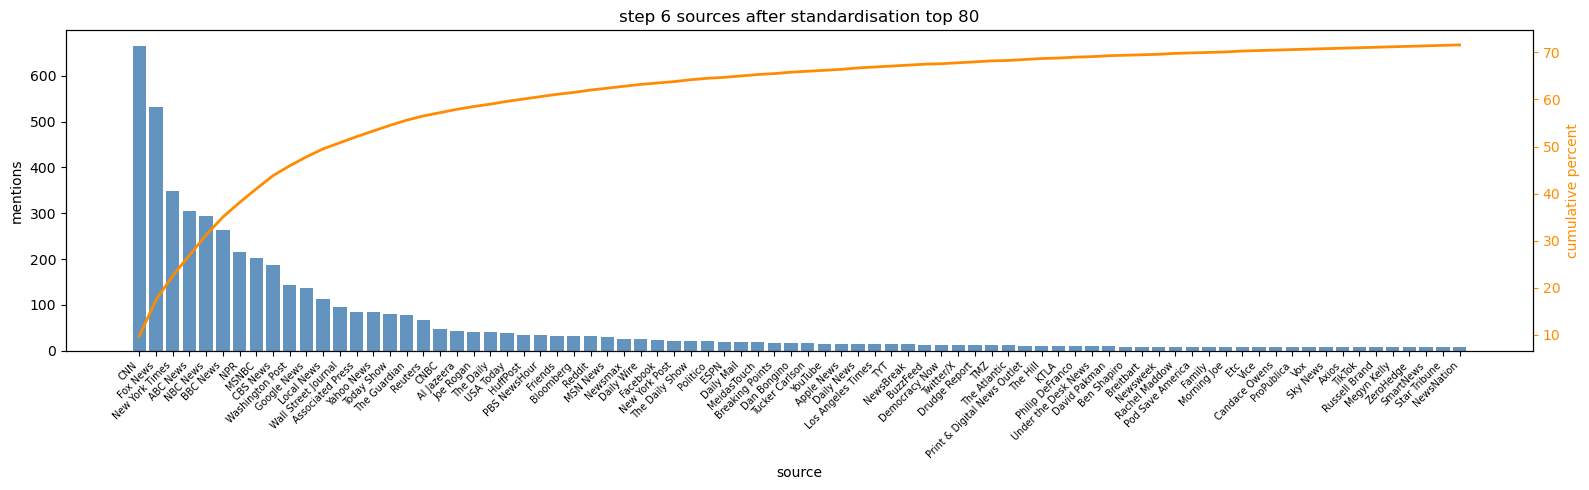

In [32]:
fig, ax = plt.subplots(figsize=(16, 5))
ax2 = ax.twinx()
tp = top6.head(80) # show top 80
ax.bar(range(len(tp)), tp['count'], color='steelblue', alpha=0.85) # same blue as steps 3 and 4
ax2.plot(range(len(tp)), tp['cum_pct'].values, color='darkorange', lw=2)
ax.set_xticks(range(len(tp)))
ax.set_xticklabels(tp['source'], rotation=45, ha='right', fontsize=7)
ax.set_xlabel('source')
ax.set_ylabel('mentions')
ax2.set_ylabel('cumulative percent', color='darkorange')
ax2.tick_params(axis='y', colors='darkorange')
ax.set_title('step 6 sources after standardisation top 80')
plt.tight_layout()
plt.savefig('fig3_step6_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10: Create subcategories and decide on threshold

A subcategory is the combination of outlet group and source category.
For example TV/Radio and National News Channel gives the subcategory TV/Radio | National News Channel.
First we look at how many unique respondents mentioned a source from each subcategory.
Then we decide on a minimum number to keep a subcategory as a predictor in the regression.

In [33]:
meta_clean['outlet_group'] = meta_clean['outlet'].map(OUTLET_GROUP) # add outlet group column
meta_clean['subcategory'] = meta_clean['outlet_group'] + ' | ' + meta_clean['category'] # create subcategory column

In [34]:
# count how many unique respondents mentioned a source from each subcategory
subcat_resp = (
    meta_clean.groupby('subcategory')['prolific_id']
    .nunique()
    .reset_index()
    .rename(columns={'prolific_id': 'unique_respondents'})
    .sort_values('unique_respondents', ascending=False)
)
subcat_resp

,subcategory,unique_respondents
24,TV/Radio | National News Channel,433
12,Print/Online | Print & Digital News Outlet,341
8,Print/Online | National News Channel,317
11,Print/Online | Non-News Related,252
19,Social Media | Non-News Related,236
16,Social Media | National News Channel,185
29,TV/Radio | Radio and Podcasts,182
32,YouTube | National News Channel,168
23,TV/Radio | Local News,167
20,Social Media | Print & Digital News Outlet,160


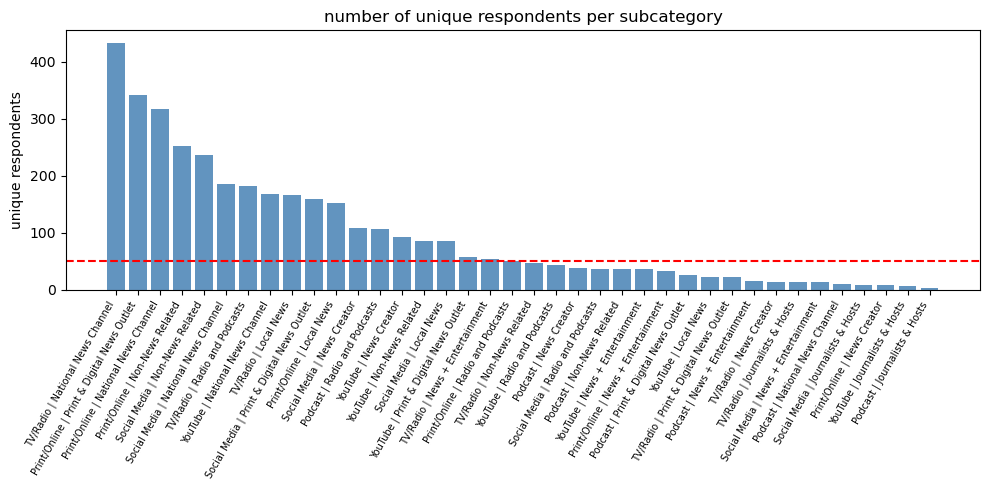

In [35]:
# histogram showing the distribution of respondent counts across subcategories
# each bar is a subcategory, height is how many respondents mentioned it
# this helps decide where to put the threshold
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(subcat_resp)), subcat_resp['unique_respondents'], color='steelblue', alpha=0.85)
ax.axhline(y=50, color='red', linestyle='--', lw=1.5) # red line at threshold 50
ax.set_xticks(range(len(subcat_resp)))
ax.set_xticklabels(subcat_resp['subcategory'], rotation=60, ha='right', fontsize=7)
ax.set_ylabel('unique respondents')
ax.set_title('number of unique respondents per subcategory')
plt.tight_layout()
plt.savefig('fig_subcat_respondents.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# keep only subcategories where more than 50 unique respondents mentioned a source
# 50 is chosen because it provides enough observations for a reliable regression estimate
kept = subcat_resp[subcat_resp['unique_respondents'] > 50]['subcategory'].tolist()
# how many subcategories we keep
print(len(kept))

18


In [37]:
# which subcategories are kept
kept

['TV/Radio | National News Channel',
 'Print/Online | Print & Digital News Outlet',
 'Print/Online | National News Channel',
 'Print/Online | Non-News Related',
 'Social Media | Non-News Related',
 'Social Media | National News Channel',
 'TV/Radio | Radio and Podcasts',
 'YouTube | National News Channel',
 'TV/Radio | Local News',
 'Social Media | Print & Digital News Outlet',
 'Print/Online | Local News',
 'Social Media | News Creator',
 'Podcast | Radio and Podcasts',
 'YouTube | News Creator',
 'YouTube | Non-News Related',
 'Social Media | Local News',
 'YouTube | Print & Digital News Outlet',
 'TV/Radio | News + Entertainment']

In [38]:
filtered = meta_clean[meta_clean['subcategory'].isin(kept)].copy() # keep only rows from kept subcategories

# count version: how many unique sources each respondent mentioned per subcategory
pivot_count = (
    filtered.groupby(['prolific_id', 'subcategory'])['source_unified']
    .nunique()
    .reset_index()
    .rename(columns={'source_unified': 'n_sources'})
)
media_count = pivot_count.pivot(
    index='prolific_id', columns='subcategory', values='n_sources'
).fillna(0).astype(int).reset_index()

# binary version: 1 if the respondent mentioned at least one source in this subcategory
media_binary = (media_count.set_index('prolific_id') > 0).astype(int).reset_index()

subcat_cols = sorted([c for c in media_count.columns if c != 'prolific_id'])
media_count = media_count[['prolific_id'] + subcat_cols] # reorder columns
media_binary = media_binary[['prolific_id'] + subcat_cols]

# shape of the count table (rows are respondents columns are subcategories)
media_count.shape

(836, 19)

In [ ]:
 
media_count.to_csv('respondent_subcategory_counts.csv', index=False)
media_binary.to_csv('respondent_subcategory_binary.csv', index=False)